In [1]:
import pandas as pd
import scanpy as sc
import anndata as ad
from pathlib import Path

In [2]:
figdir = Path("/gpfs/Home/esm5360/bulk_rna_seq_analysis/figures/combined_analysis")
figdir.mkdir(parents=True, exist_ok=True)
sc.settings.figdir = str(figdir)

## Merging WT and KO

In [3]:
wt_filtered_adata = sc.read_h5ad("/gpfs/Home/esm5360/bulk_rna_seq_analysis/data/wt_filtered_adata.h5ad")
ko_filtered_adata = sc.read_h5ad("/gpfs/Home/esm5360/bulk_rna_seq_analysis/data/ko_filtered_adata.h5ad")

In [4]:
common_genes = ko_filtered_adata.var_names.intersection(wt_filtered_adata.var_names)

ko = ko_filtered_adata[:, common_genes].copy()
wt = wt_filtered_adata[:, common_genes].copy()

ko.obs['condition'] = 'KO_Sample01'
wt.obs['condition'] = 'WT_Sample01'

adata = sc.concat([ko, wt], label='batch', keys=['KO_Sample01', 'WT_Sample01'])

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

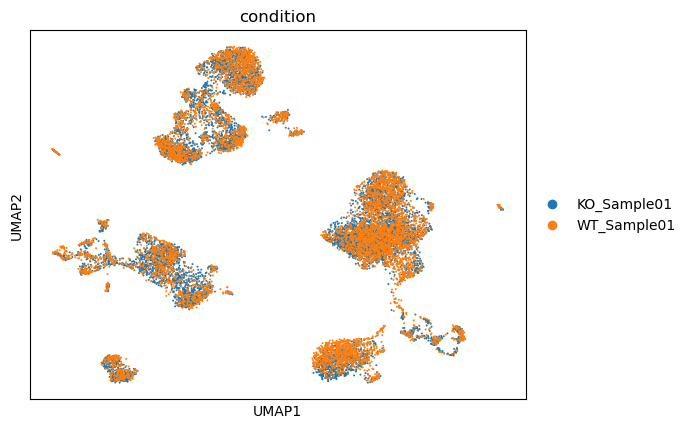

In [6]:
# Find clusters (Seurat FindClusters)
sc.tl.leiden(adata, resolution=0.05, flavor="igraph") 

# Visualize
sc.pl.umap(adata, color=['condition'], groups=['KO_Sample01', 'WT_Sample01'])

/tmp/ipykernel_198014/3273052819.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centroids = df.groupby('leiden')[['UMAP1', 'UMAP2']].mean()


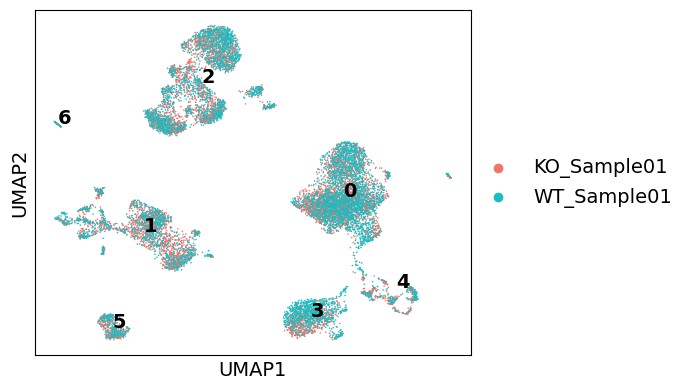

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
colors = {'KO_Sample01': '#f3746d', 'WT_Sample01': '#19bdc2'}

# Plot UMAP colored by condition
sc.pl.umap(adata, color='condition', show=False, palette=colors, size=5, ax=ax)

# Get UMAP coords
coords = adata.obsm['X_umap']
df = pd.DataFrame(coords, columns=['UMAP1', 'UMAP2'])
df['leiden'] = adata.obs['leiden'].values

# Compute cluster centroids
centroids = df.groupby('leiden')[['UMAP1', 'UMAP2']].mean()

# Label clusters
for cluster, (x, y) in centroids.iterrows():
    plt.text(x, y, cluster, fontsize=14, weight='bold')
    
plt.legend(
    bbox_to_anchor=(1.0, 0.5), loc='center left', borderaxespad=0.,
    frameon=False, fontsize=14
)
plt.xlabel('UMAP1', fontsize=14)
plt.ylabel('UMAP2', fontsize=14)
plt.title('', fontsize=16)
plt.tight_layout()
fig.savefig(figdir / "combined_umap.png", dpi=300)
plt.show()

In [8]:
adata.write_h5ad("/gpfs/Home/esm5360/bulk_rna_seq_analysis/data/combined_adata.h5ad")

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value

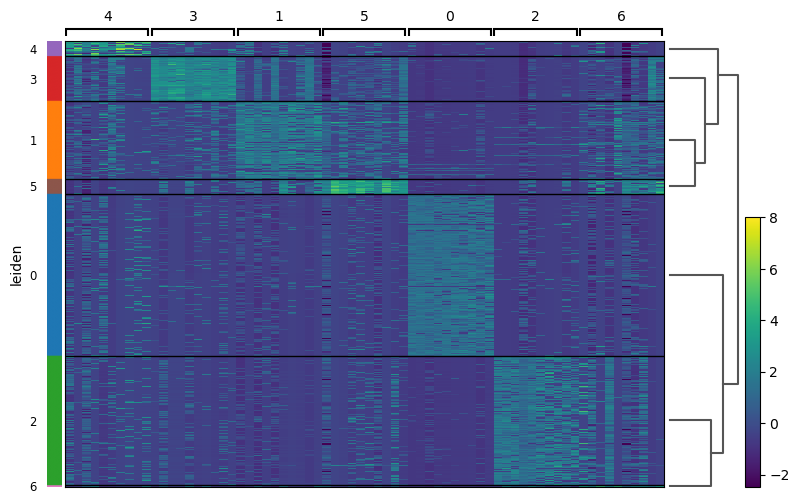

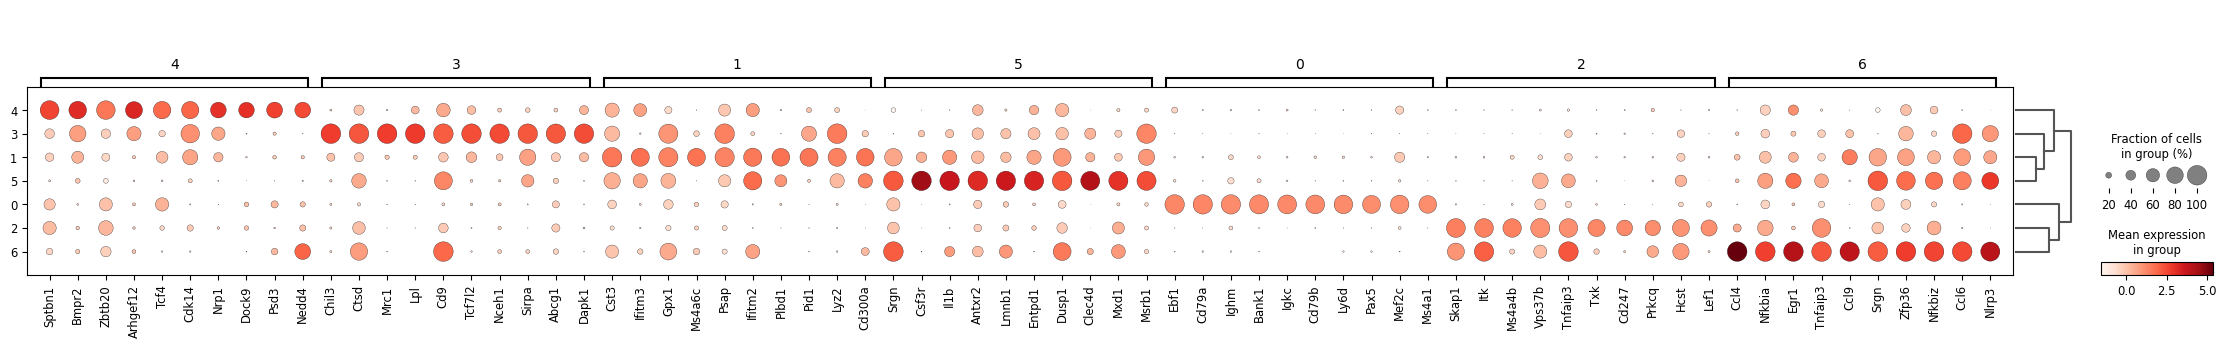

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,Ebf1,99.544540,NaN,0.0,0.0,1.0,1.0
1,0,Cd79a,99.466721,NaN,0.0,0.0,1.0,1.0
2,0,Ighm,98.596886,NaN,0.0,0.0,1.0,1.0
3,0,Bank1,98.016518,NaN,0.0,0.0,1.0,1.0
4,0,Igkc,96.425911,NaN,0.0,0.0,1.0,1.0


In [9]:
# Differential expression between conditions
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    key_added="wilcoxon",
    method="wilcoxon",
    use_raw=False,
    pts=True,
)

# sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, key="wilcoxon")
sc.tl.dendrogram(adata, groupby="leiden", use_rep="X_pca", key_added="leiden_dendrogram")

sc.pl.rank_genes_groups_heatmap(adata, n_genes=10, key="wilcoxon", groupby="leiden", save="clusters_diff_expr.png")
sc.pl.rank_genes_groups_dotplot(adata, n_genes=10, key="wilcoxon", groupby="leiden", save="clusters_diff_expr.png")

de_table = sc.get.rank_genes_groups_df(adata, group=None, key="wilcoxon")
de_table.to_csv(
    "/gpfs/Home/esm5360/bulk_rna_seq_analysis/results/condition_de_wilcoxon.csv",
    index=False,
)

de_table.head()